# SP(k) Baryon Suppression Demo

This notebook compares non-linear matter power with and without SP(k), then validates the SP(k) suppression curve against `pyspk`.

## What this notebook does

1. Build a baseline non-linear model (`mead2020`) and an SP(k)-enabled model with the same cosmology.
2. Plot the full spectra and the suppression ratio.
3. Compare CAMB SP(k) vs `pyspk` suppression and show relative error.

## Notes

- SP(k) should not be combined with HMCode baryon-feedback models (e.g. `halofit_version='mead2020_feedback'`).


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import warnings

import numpy as np
import pyspk
from matplotlib import pyplot as plt

import camb
from camb import model

warnings.filterwarnings("ignore")

print(f"Using CAMB {camb.__version__} installed at {os.path.dirname(camb.__file__)}")
print(f"Using pyspk {pyspk.__version__}")

Using CAMB 1.6.7 installed at /cosma8/data/dp004/fkgm22/camb_dev/CAMB/camb
Using pyspk 2.0.0


In [2]:
# Cosmology + k/z sampling
minkh, maxkh, npoints = 1e-4, 12.0, 400
z_samples = [0.0, 0.125, 1.0]

k_per_logint = 50

# Baseline non-linear model (HMCode, no SPk)
pars_base = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, As=2e-9, ns=0.965)
pars_base.set_matter_power(redshifts=z_samples, kmax=maxkh, k_per_logint=k_per_logint, silent=True)
pars_base.NonLinear = model.NonLinear_both
pars_base.NonLinearModel = camb.Halofit()
pars_base.NonLinearModel.set_params(halofit_version="mead2020")

results_base = camb.get_results(pars_base)
kh0, z0, pk0 = results_base.get_matter_power_spectrum(minkh=minkh, maxkh=maxkh, npoints=npoints)

# SP(k) on top of the same base model (kind=1, power_law)
pars_spk = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, As=2e-9, ns=0.965)
pars_spk.set_matter_power(redshifts=z_samples, kmax=maxkh, k_per_logint=k_per_logint, silent=True)
pars_spk.NonLinear = model.NonLinear_both

spk_model = camb.SPkNonLinear()
spk_model.set_params(
    SPk_feedback=True,
    SPk_SO=200,
    SPk_relation_kind=1,
    SPk_fb_a=0.4,
    SPk_fb_pow=0.3,
    SPk_fb_pivot=10**13.5,
    halofit_version="mead2020",
)
pars_spk.NonLinearModel = spk_model

results_spk = camb.get_results(pars_spk)
kh1, z1, pk1 = results_spk.get_matter_power_spectrum(minkh=minkh, maxkh=maxkh, npoints=npoints)

assert np.allclose(kh0, kh1)
assert np.allclose(z0, z1)
z = np.array(z0)
print("redshifts:", z)
print("k_per_logint:", k_per_logint)

redshifts: [0.    0.125 1.   ]
k_per_logint: 50


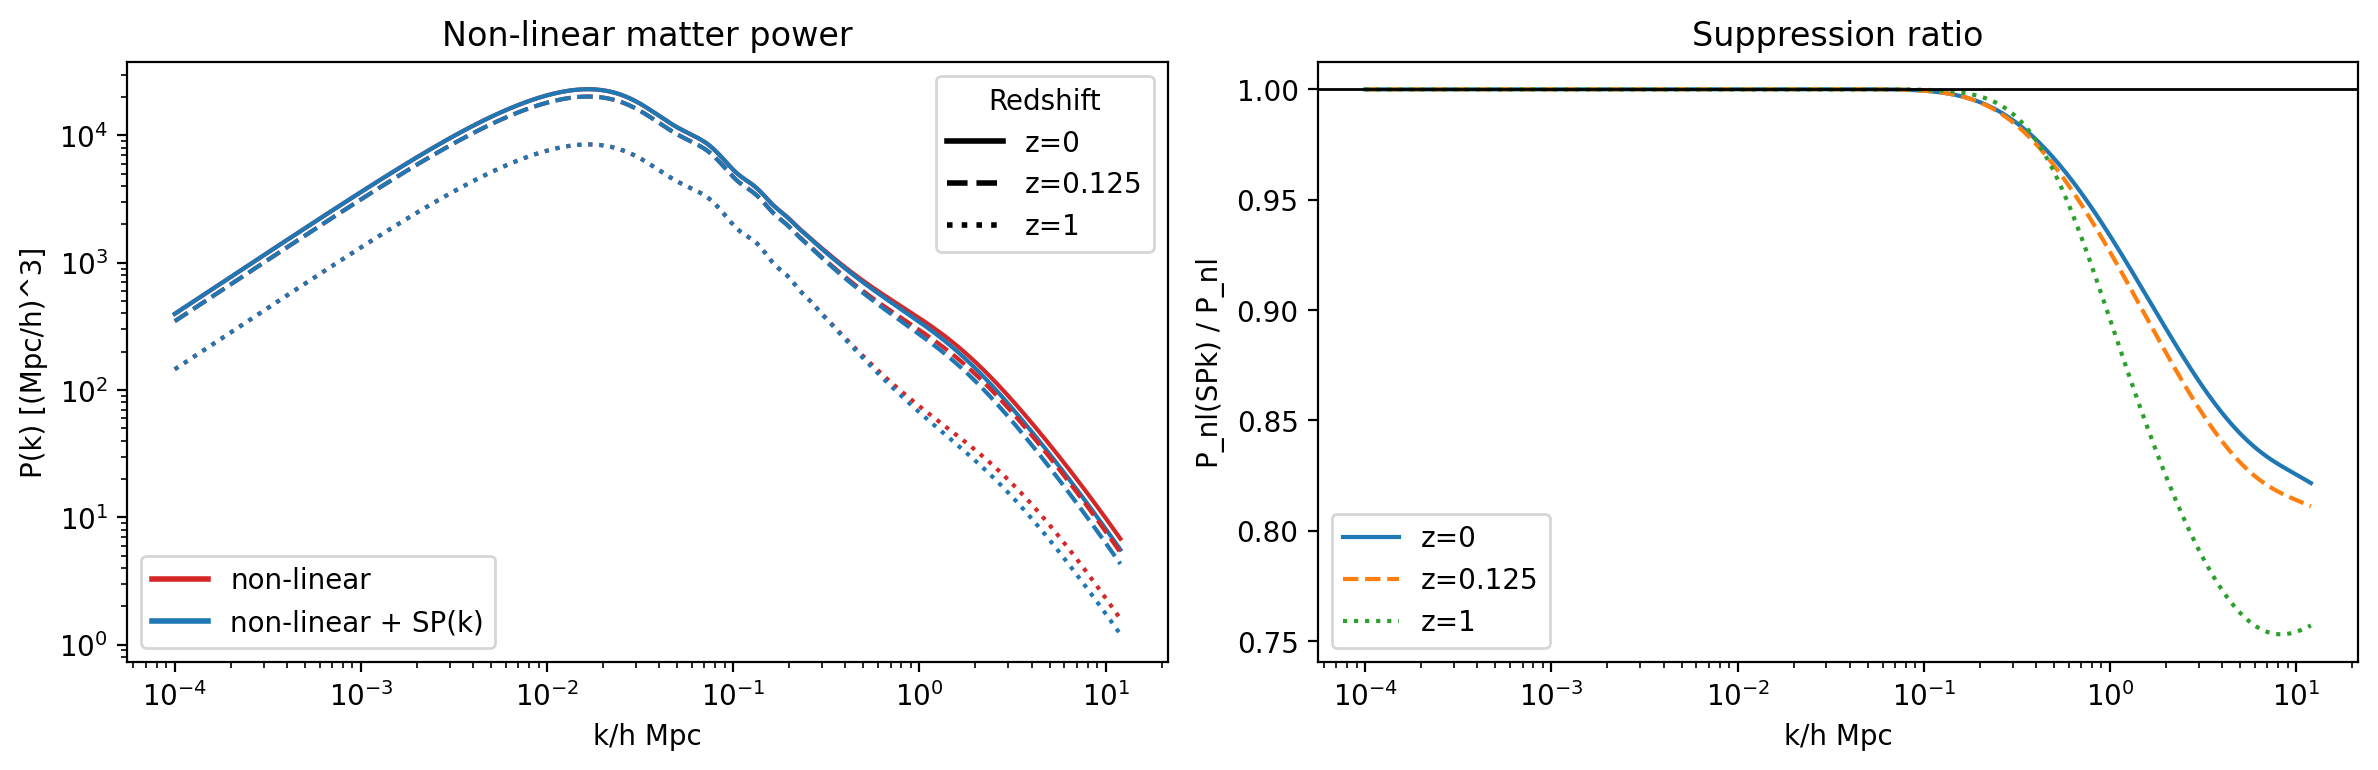

In [3]:
# Plot non-linear vs non-linear+SP(k)
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(12, 4), squeeze=False)
ax_pk = axes[0, 0]
ax_sup = axes[0, 1]
linestyles = ["-", "--", ":", "-."]

for i, redshift in enumerate(z):
    ls = linestyles[i % len(linestyles)]
    ax_pk.loglog(kh0, pk0[i, :], color="C3", ls=ls)
    ax_pk.loglog(kh1, pk1[i, :], color="C0", ls=ls)
ax_pk.set_xlabel("k/h Mpc")
ax_pk.set_ylabel("P(k) [(Mpc/h)^3]")
ax_pk.set_title("Non-linear matter power")

model_handles = [
    Line2D([], [], color="C3", lw=2, label="non-linear"),
    Line2D([], [], color="C0", lw=2, label="non-linear + SP(k)"),
]
redshift_handles = [
    Line2D([], [], color="k", lw=2, ls=linestyles[i % len(linestyles)], label=f"z={float(redshift):g}")
    for i, redshift in enumerate(z)
]
leg_model = ax_pk.legend(handles=model_handles, loc="lower left")
ax_pk.add_artist(leg_model)
ax_pk.legend(handles=redshift_handles, title="Redshift", loc="upper right")

for i, redshift in enumerate(z):
    ls = linestyles[i % len(linestyles)]
    ax_sup.semilogx(kh0, pk1[i, :] / pk0[i, :], ls=ls, label=f"z={float(redshift):g}")
ax_sup.axhline(1.0, color="k", lw=1)
ax_sup.set_xlabel("k/h Mpc")
ax_sup.set_ylabel("P_nl(SPk) / P_nl")
ax_sup.set_title("Suppression ratio")
ax_sup.legend(loc="lower left")

plt.tight_layout()

## Interpreting the validation plot

- Top panel: suppression factor from CAMB SP(k) and `pyspk` (should overlap closely).
- Bottom panel: relative error, defined as `CAMB / pyspk - 1`, shown on a ±1% axis.
- Vertical dashed line at `k=8 h/Mpc`: approximate `pyspk` Nyquist reference.


Max relative error between CAMB SP(k) and pyspk:
z=0:  k<=8 -> 2.10e-09,  k<=12 -> 9.03e-05
z=0.125:  k<=8 -> 2.00e-09,  k<=12 -> 6.55e-05
z=1:  k<=8 -> 2.15e-09,  k<=12 -> 8.01e-05


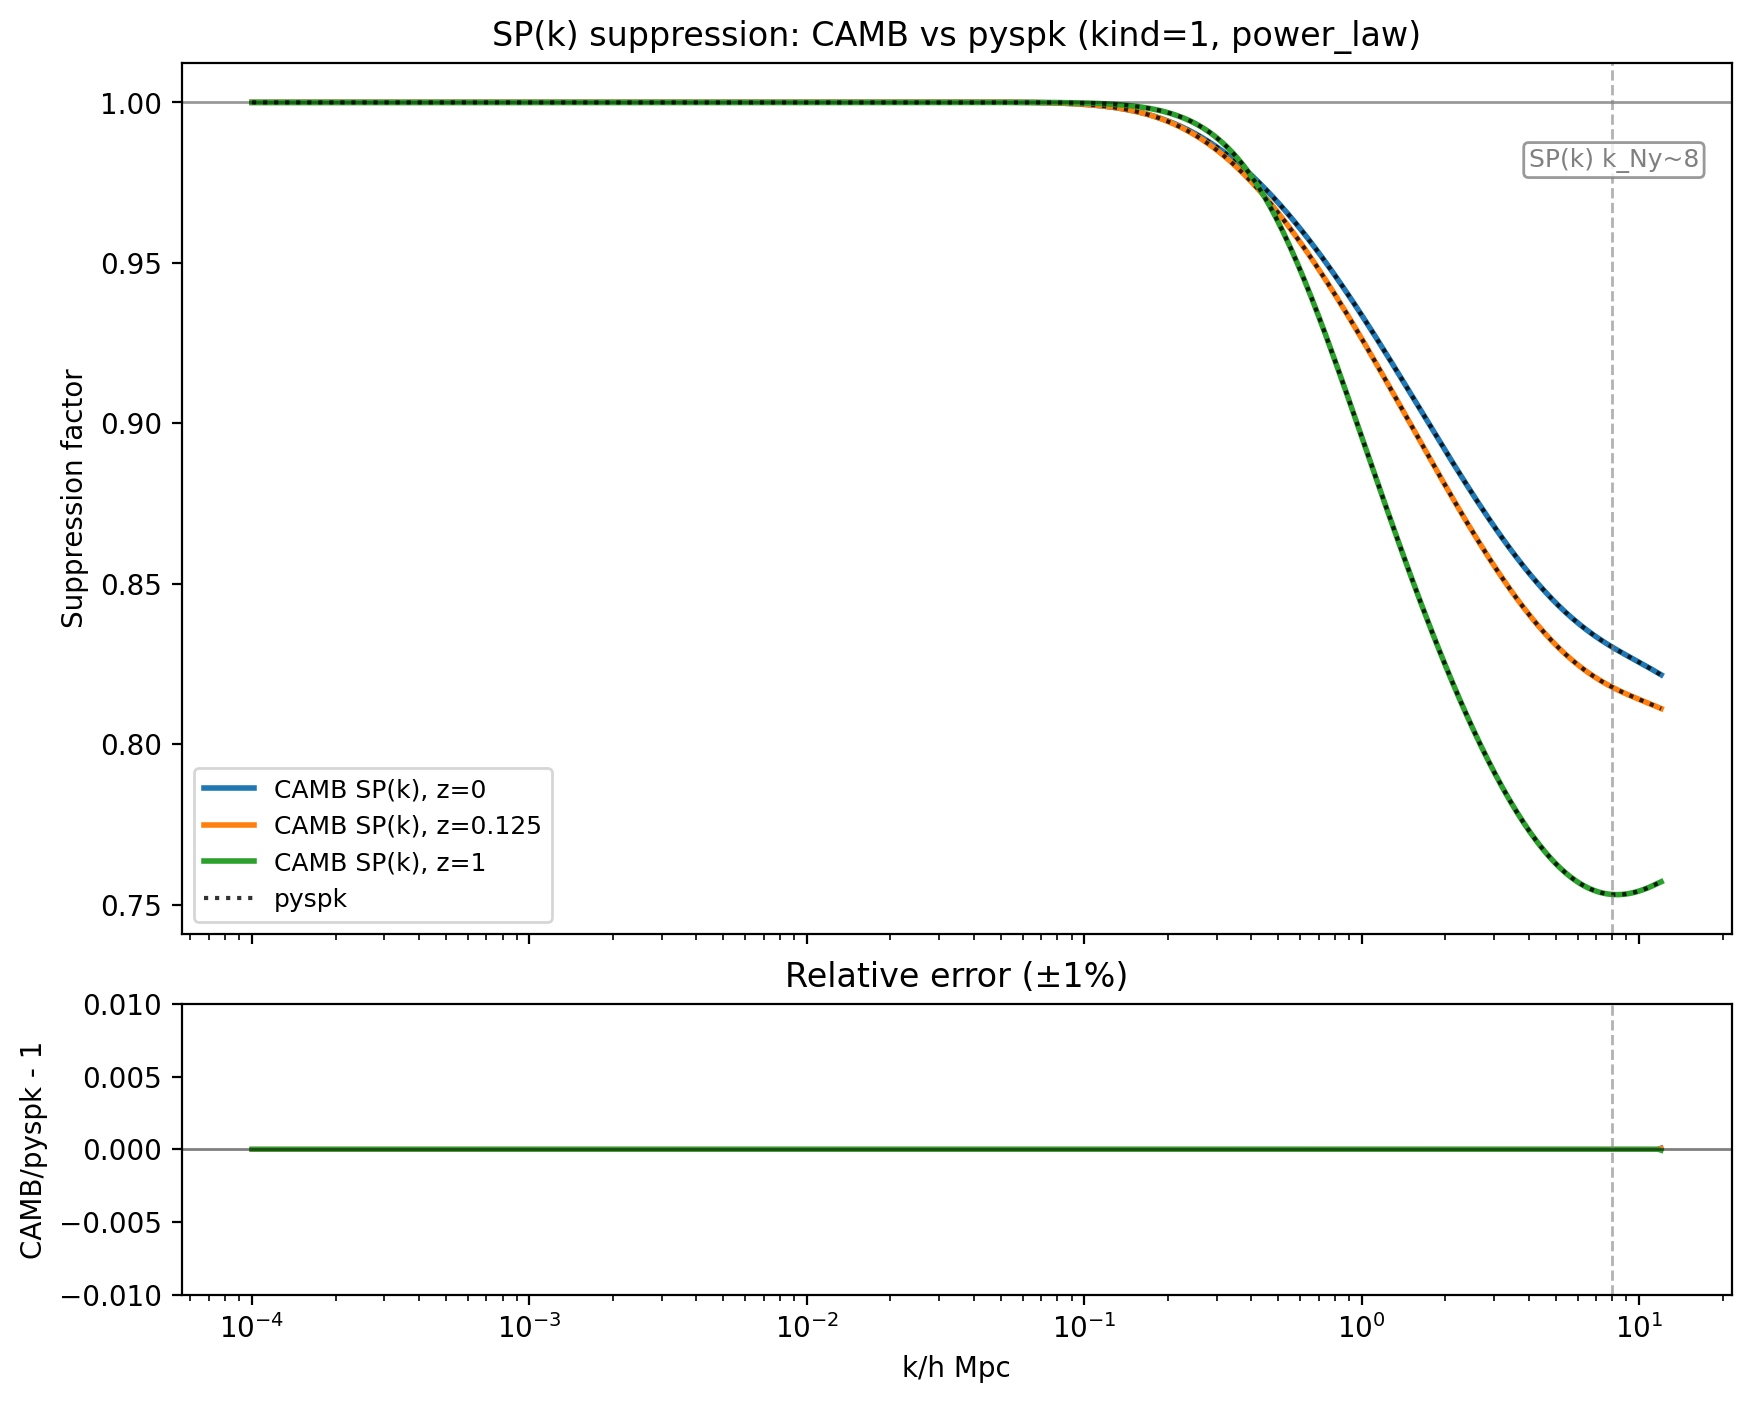

In [4]:
# Verify suppression factor against pyspk and show implementation error
# kind=1 (power_law) has no cosmology dependence — no cosmo object needed
pyspk_sup_list = []
for redshift in z:
    k_pyspk, sup_pyspk = pyspk.sup_model(
        SO=200,
        z=float(redshift),
        fb_a=0.4,
        fb_pow=0.3,
        fb_pivot=10**13.5,
        k_array=kh0,
        verbose=False,
    )
    assert np.allclose(k_pyspk, kh0)
    pyspk_sup_list.append(sup_pyspk)

k_compare_max = 12.0
mask_plot = kh0 <= k_compare_max

fig2, axes2 = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    squeeze=False,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.12},
)
ax2 = axes2[0, 0]
ax3 = axes2[1, 0]

colors = ["C0", "C1", "C2"]
camb_handles = []
pyspk_handle = None

for i, redshift in enumerate(z):
    color = colors[i % len(colors)]
    camb_sup = pk1[i, :] / pk0[i, :]
    py_sup = pyspk_sup_list[i]
    valid = mask_plot & np.isfinite(camb_sup) & np.isfinite(py_sup) & (np.abs(py_sup) > 1e-30)

    (line_camb,) = ax2.semilogx(
        kh0[valid], camb_sup[valid], color=color, ls="-", lw=2, label=f"CAMB SP(k), z={float(redshift):g}"
    )
    camb_handles.append(line_camb)

    if pyspk_handle is None:
        (pyspk_handle,) = ax2.semilogx(kh0[valid], py_sup[valid], color="k", ls=":", lw=1.5, alpha=0.8, label="pyspk")
    else:
        ax2.semilogx(kh0[valid], py_sup[valid], color="k", ls=":", lw=1.5, alpha=0.8, label=None)

    ratio_err = camb_sup[valid] / py_sup[valid] - 1.0
    ax3.semilogx(kh0[valid], ratio_err, color=color, ls="-", lw=1.8, label=f"z={float(redshift):g}")

ax2.axhline(1.0, color="k", lw=1, alpha=0.4)
ax2.set_ylabel("Suppression factor")
ax2.set_title("SP(k) suppression: CAMB vs pyspk (kind=1, power_law)")
if pyspk_handle is not None:
    ax2.legend(handles=[*camb_handles, pyspk_handle], loc="lower left", fontsize=9)
else:
    ax2.legend(loc="lower left", fontsize=9)

ax3.axhline(0.0, color="k", lw=1, alpha=0.5)
ax3.set_xlabel("k/h Mpc")
ax3.set_ylabel("CAMB/pyspk - 1")
ax3.set_ylim(-0.01, 0.01)
ax3.set_title("Relative error (±1%)")

# Reference marker: pyspk Nyquist limit
ax2.axvline(8.0, color="gray", lw=1, ls="--", alpha=0.6)
ax3.axvline(8.0, color="gray", lw=1, ls="--", alpha=0.6)
ax2.text(
    8.0 * 0.5,
    0.98,
    "SP(k) k_Ny~8",
    color="gray",
    fontsize=9,
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8, boxstyle="round,pad=0.2"),
)

plt.tight_layout()

print("Max relative error between CAMB SP(k) and pyspk:")
for i, redshift in enumerate(z):
    camb_sup = pk1[i, :] / pk0[i, :]
    py_sup = pyspk_sup_list[i]
    valid8 = (kh0 <= 8.0) & np.isfinite(camb_sup) & np.isfinite(py_sup) & (np.abs(py_sup) > 1e-30)
    valid12 = (kh0 <= 12.0) & np.isfinite(camb_sup) & np.isfinite(py_sup) & (np.abs(py_sup) > 1e-30)
    rel8 = np.max(np.abs(camb_sup[valid8] / py_sup[valid8] - 1.0))
    rel12 = np.max(np.abs(camb_sup[valid12] / py_sup[valid12] - 1.0))
    print(f"z={float(redshift):g}:  k<=8 -> {rel8:.2e},  k<=12 -> {rel12:.2e}")